# Book Recommender Project

#### Personalized book suggestions using data, NLP, and Streamlit

Books Scrapped from [goodreads](https://www.goodreads.com/book/popular_by_date/2019).
* Years: 1975-2024

Books API from [openlibrary](https://openlibrary.org/developers/api). 
* Years: 1900-1975

Developed by: Bryan Calderon

Extracting the 10 most popular books per year!

## **EDA**

* Importing libraries

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
from urllib.parse import urljoin
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

* Loading data sets

In [4]:
df_good = pd.read_csv("../data/GoodBooks_clean.csv")
df_API = pd.read_csv("../data/API_Books_clean.csv")
print(df_good.info())
print("--"* 25)
print(df_API.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484 entries, 0 to 483
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   source_year     484 non-null    int64  
 1   book_url        484 non-null    object 
 2   source          484 non-null    object 
 3   title           484 non-null    object 
 4   author          484 non-null    object 
 5   average_rating  484 non-null    float64
 6   ratings_count   484 non-null    int64  
 7   reviews_count   484 non-null    int64  
 8   description     484 non-null    object 
 9   genres          484 non-null    object 
 10  pages           484 non-null    int64  
 11  image_url       484 non-null    object 
dtypes: float64(1), int64(4), object(7)
memory usage: 45.5+ KB
None
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 745 entries, 0 to 744
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtyp

* Convining data sets

In [5]:
# We define the common columns
common_columns = [
    "source_year",
    "title",
    "author",
    "average_rating",
    "ratings_count",
    "reviews_count",
    "description",
    "genres",
    "pages",
    "publisher",
    "book_url",
    "image_url",
    "source"]

df_good["publisher"] = "Unknown"
df_good = df_good[common_columns]
df_API = df_API[common_columns]

In [6]:
df3 = pd.concat([df_good, df_API], ignore_index=True)

In [7]:
df3.describe()

,source_year,average_rating,ratings_count,reviews_count,pages
count,1229.000000,1229.000000,1.229000e+03,1229.000000,484.000000
mean,1962.242474,4.022999,4.056924e+05,23057.337673,410.154959
std,35.708667,0.374192,8.989156e+05,49692.396591,191.539515
min,1900.000000,1.000000,1.000000e+00,0.000000,32.000000
25%,1932.000000,3.860000,1.100000e+01,0.000000,291.750000
50%,1962.000000,4.060000,4.500000e+01,0.000000,375.000000
75%,1993.000000,4.250000,4.478590e+05,18589.000000,483.000000
max,2024.000000,5.000000,1.163572e+07,405524.000000,1312.000000


In [8]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1229 entries, 0 to 1228
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   source_year     1229 non-null   int64  
 1   title           1229 non-null   object 
 2   author          1229 non-null   object 
 3   average_rating  1229 non-null   float64
 4   ratings_count   1229 non-null   int64  
 5   reviews_count   1229 non-null   int64  
 6   description     1229 non-null   object 
 7   genres          1229 non-null   object 
 8   pages           484 non-null    float64
 9   publisher       1229 non-null   object 
 10  book_url        1229 non-null   object 
 11  image_url       1229 non-null   object 
 12  source          1229 non-null   object 
dtypes: float64(2), int64(3), object(8)
memory usage: 124.9+ KB


In [9]:
# Using median to fill null on pages variables for modeling
median_pages = df3["pages"].median()
df3["pages"] = df3["pages"].fillna(median_pages).astype(int)  

# Sorting data by year
df3 = df3.sort_values(by="source_year", ascending=True).reset_index(drop=True)

* **First analysis and exploration** 

In [10]:
df3["author"].value_counts().head(10)
# Here also can say that the number of books by author

author
Agatha Christie         60
Georgette Heyer         25
Stephen  King           21
L. Frank Baum           15
Isaac Asimov            13
Robert A. Heinlein      13
Sarah J. Maas           13
Lucy Maud Montgomery    13
Roald Dahl              11
Edgar Rice Burroughs    11
Name: count, dtype: int64

NOTE: Value counts for authors shows that the most common is Agatha Christie

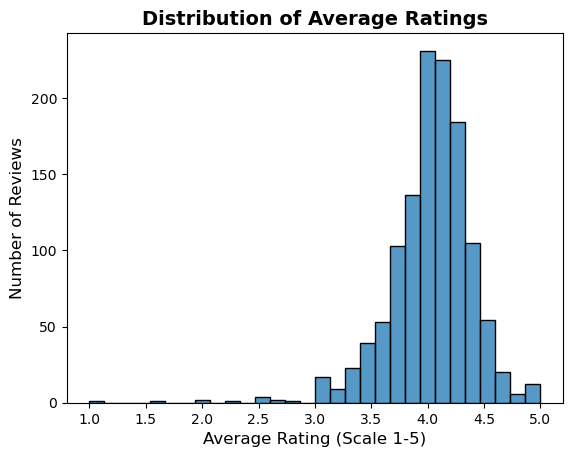

In [11]:
sns.histplot(df3["average_rating"], bins=30)
plt.title("Distribution of Average Ratings", fontsize=14, fontweight="bold")
plt.xlabel("Average Rating (Scale 1-5)", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)
plt.show()

In [12]:
top_popular_books = (
    df3.sort_values("ratings_count", ascending=False)
    [["title", "author", "source_year", "average_rating", "ratings_count"]]
    .head(10))
top_popular_books

,title,author,source_year,average_rating,ratings_count
965,Harry Potter and the Philosopher's Stone,J.K. Rowling,1997,4.47,11635724
1067,The Hunger Games,Suzanne Collins,2008,4.35,10120960
1043,Twilight,Stephenie Meyer,2005,3.68,7426050
1101,The Fault in Our Stars,John Green,2012,4.12,5813639
980,Harry Potter and the Prisoner of Azkaban,J.K. Rowling,1999,4.58,4956577
1149,It Ends with Us,Colleen Hoover,2016,4.07,4743702
975,Harry Potter and the Chamber of Secrets,J.K. Rowling,1998,4.43,4591042
1100,Divergent,Veronica Roth,2011,4.13,4442400
1131,A Court of Thorns and Roses,Sarah J. Maas,2015,4.15,4426212
995,Harry Potter and the Goblet of Fire,J.K. Rowling,2000,4.57,4282921


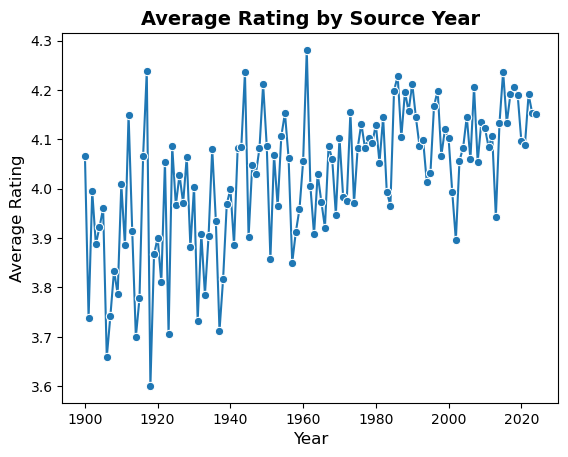

In [ ]:
avg_rating_year = (df3.groupby("source_year")["average_rating"]
    .mean()
    .reset_index())

sns.lineplot(data=avg_rating_year,
    x="source_year",
    y="average_rating",
    marker="o")

plt.title("Average Rating by Source Year", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)
plt.show()


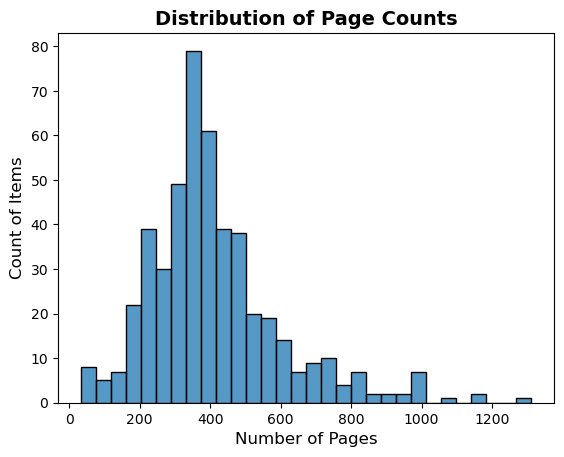

In [61]:
df_filtered = df3[df3["pages"] != 375].copy()
sns.histplot(df_filtered["pages"], bins=30)
plt.title("Distribution of Page Counts", fontsize=14, fontweight="bold")
plt.xlabel("Number of Pages", fontsize=12)
plt.ylabel("Count of Items", fontsize=12)
plt.show()

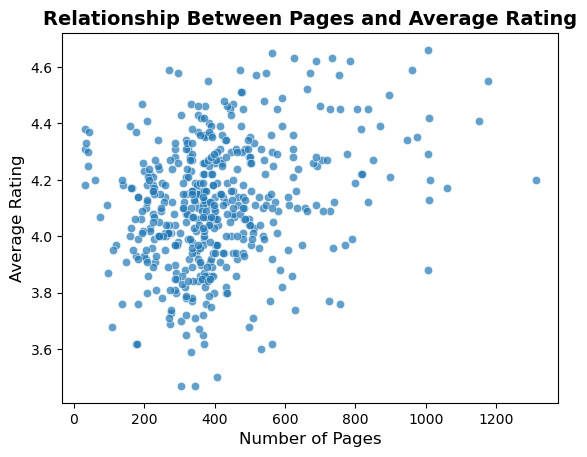

In [13]:
df_filtered = df3[df3["pages"] != 375].copy()
sns.scatterplot(
    data=df_filtered,
    x="pages",
    y="average_rating",
    alpha=0.7)

plt.title("Relationship Between Pages and Average Rating", fontsize=14, fontweight="bold")
plt.xlabel("Number of Pages", fontsize = 12)
plt.ylabel("Average Rating", fontsize = 12)
plt.show()

In [14]:
df_genres = df3.copy()
df_genres["genres"] = df_genres["genres"].fillna("").str.lower()
df_genres["genres"] = df_genres["genres"].str.split(r"\s*,\s*")
df_genres = df_genres.explode("genres")
df_genres = df_genres[df_genres["genres"] != ""]
df_genres.head()


,source_year,title,author,average_rating,ratings_count,reviews_count,description,genres,pages,publisher,book_url,image_url,source
0,1900,The Hound of the Baskervilles,Arthur Conan Doyle,4.016667,60,0,The Hound of the Baskervilles Arthur Conan Doy...,crime novel,375,"Marti Yayinlari, Zeplin Kitap, Leopard, Saddle...",https://openlibrary.org/works/OL262454W,https://covers.openlibrary.org/b/id/8063264-M.jpg,Open Library API
0,1900,The Hound of the Baskervilles,Arthur Conan Doyle,4.016667,60,0,The Hound of the Baskervilles Arthur Conan Doy...,english civil war,375,"Marti Yayinlari, Zeplin Kitap, Leopard, Saddle...",https://openlibrary.org/works/OL262454W,https://covers.openlibrary.org/b/id/8063264-M.jpg,Open Library API
0,1900,The Hound of the Baskervilles,Arthur Conan Doyle,4.016667,60,0,The Hound of the Baskervilles Arthur Conan Doy...,mires,375,"Marti Yayinlari, Zeplin Kitap, Leopard, Saddle...",https://openlibrary.org/works/OL262454W,https://covers.openlibrary.org/b/id/8063264-M.jpg,Open Library API
0,1900,The Hound of the Baskervilles,Arthur Conan Doyle,4.016667,60,0,The Hound of the Baskervilles Arthur Conan Doy...,tors,375,"Marti Yayinlari, Zeplin Kitap, Leopard, Saddle...",https://openlibrary.org/works/OL262454W,https://covers.openlibrary.org/b/id/8063264-M.jpg,Open Library API
0,1900,The Hound of the Baskervilles,Arthur Conan Doyle,4.016667,60,0,The Hound of the Baskervilles Arthur Conan Doy...,tombs,375,"Marti Yayinlari, Zeplin Kitap, Leopard, Saddle...",https://openlibrary.org/works/OL262454W,https://covers.openlibrary.org/b/id/8063264-M.jpg,Open Library API


In [15]:
top_genres = (
    df_genres["genres"]
    .value_counts()
    .head(20)
    .reset_index())

top_genres.columns = ["genre", "book_count"]

top_genres

,genre,book_count
0,fiction,2176
1,fantasy,286
2,general,274
3,science fiction,250
4,romance,222
5,audiobook,215
6,juvenile fiction,174
7,mystery,168
8,classics,138
9,historical,130


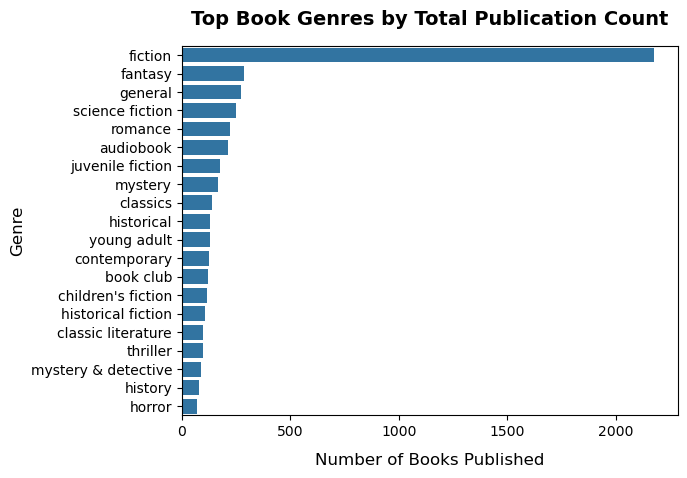

In [16]:
sns.barplot(
    data=top_genres,
    x="book_count",
    y="genre")
plt.title("Top Book Genres by Total Publication Count", fontsize=14, pad=15, weight="bold")
plt.xlabel("Number of Books Published", fontsize=12, labelpad=10)
plt.ylabel("Genre", fontsize=12)
plt.show()


Fiction dominates the gender. If we include genre_fiction in the encoded variables, K-Means may separate books partly based on this very broad label instead of more informative like romance, juvenile, and others.


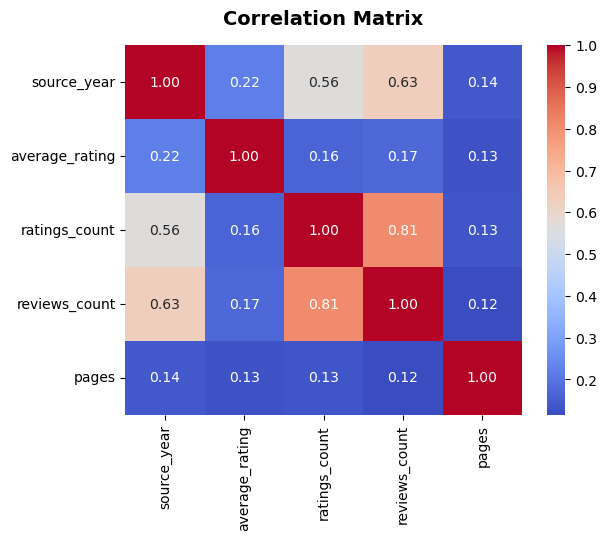

In [17]:
numeric_cols = [
    "source_year",
    "average_rating",
    "ratings_count",
    "reviews_count",
    "pages"]

corr_matrix = df3[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt =".2f")
plt.title("Correlation Matrix", fontsize=14, pad=15, weight="bold")
plt.show()

In [19]:
df3.to_csv("../data/join_API_Goodreads.csv", index=False)